# ✅ Evaluation — MAPE, Silhouette Score & Davies-Bouldin Index

---

## Overview Evaluasi

| Model | Metrik | Formula | Threshold Baik |
|---|---|---|---|
| Cohort Projection | **MAPE** | $\frac{1}{N} \sum \frac{\|\hat{y} - y\|}{y} \times 100$ | < 20% |
| K-Means | **Silhouette Score** | $\frac{b - a}{\max(a, b)}$ | > 0.5 |
| K-Means | **Davies-Bouldin Index** | $\frac{1}{K} \sum_i \max_{j \neq i} \frac{s_i + s_j}{d(c_i, c_j)}$ | < 1.0 |

---

## Referensi
- Hyndman & Koehler (2006) — *Another look at measures of forecast accuracy*, IJF 22(4)
- Rousseeuw (1987) — *Silhouettes: A graphical aid to the interpretation of cluster analysis*, JCAM 20
- Davies & Bouldin (1979) — *A cluster separation measure*, IEEE TPAMI 1(2)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.metrics import silhouette_score, davies_bouldin_score
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')
plt.rcParams.update({'figure.dpi': 120, 'axes.titlesize': 13})
DATA = '../medallion/exports/'

eval_df   = pd.read_csv(DATA + 'evaluation.csv')
mape_det  = pd.read_csv(DATA + 'mape_detail.csv')
clusters  = pd.read_csv(DATA + 'clusters.csv')
elbow     = pd.read_csv(DATA + 'elbow_data.csv')

FEATURE_COLS     = ['deficit_rate','utilisasi_norm','growth_rate','scgi_raw']
PRIORITY_COLORS  = {1:'#d62728', 2:'#ff7f0e', 3:'#bcbd22', 4:'#2ca02c'}

print('Evaluation metrics:')
eval_df[['model','metric','value','unit','status']]

Evaluation metrics:


,model,metric,value,unit,status
0,cohort_projection,MAPE,42.2300,persen,PERLU_PERBAIKAN
1,kmeans_clustering,Silhouette_Score,0.7327,rasio,BAIK
2,kmeans_clustering,Davies_Bouldin_Index,1.4145,rasio,CUKUP


## 1. MAPE — Akurasi Cohort Projection

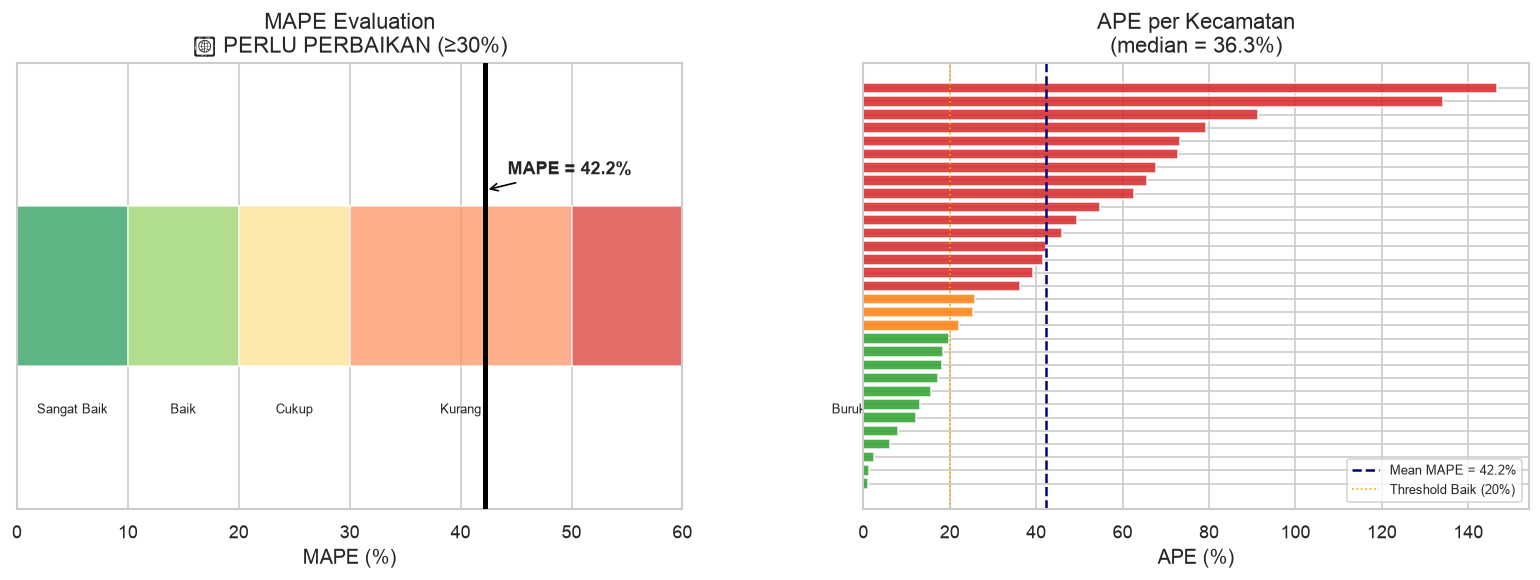

  Mean MAPE   = 42.23%  🔴 PERLU PERBAIKAN (≥30%)
  Median APE  = 36.26%
  Max APE     = 146.66%  (PABEANCANTIAN)
  Min APE     = 1.17%


In [2]:
mape_val = mape_det['ape'].mean()
mape_med = mape_det['ape'].median()

quality = ('🟢 BAIK (<20%)' if mape_val < 20
           else '🟡 CUKUP (<30%)' if mape_val < 30
           else '🔴 PERLU PERBAIKAN (≥30%)')

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Gauge-style bar
ax1 = axes[0]
thresholds = [0, 10, 20, 30, 50, 100]
labels_thresh = ['Sangat Baik', 'Baik', 'Cukup', 'Kurang', 'Buruk']
colors_thresh = ['#1a9850','#91cf60','#fee08b','#fc8d59','#d73027']
for i in range(len(thresholds)-1):
    ax1.barh(0, thresholds[i+1]-thresholds[i], left=thresholds[i],
              color=colors_thresh[i], height=0.5, alpha=0.7)
    ax1.text((thresholds[i]+thresholds[i+1])/2, -0.4, labels_thresh[i],
              ha='center', fontsize=8)
ax1.axvline(mape_val, color='black', lw=3, zorder=5)
ax1.annotate(f'MAPE = {mape_val:.1f}%', (mape_val, 0.3),
              xytext=(mape_val+2, 0.35), fontsize=11, fontweight='bold',
              arrowprops=dict(arrowstyle='->', color='black'))
ax1.set_xlim(0, 60)
ax1.set_ylim(-0.7, 0.7)
ax1.set_xlabel('MAPE (%)')
ax1.set_title(f'MAPE Evaluation\n{quality}')
ax1.set_yticks([])

# APE per kecamatan sorted
ax2 = axes[1]
mape_sorted = mape_det.sort_values('ape')
colors_ape  = ['#d62728' if v >= 30 else '#ff7f0e' if v >= 20 else '#2ca02c'
               for v in mape_sorted['ape']]
ax2.barh(range(len(mape_sorted)), mape_sorted['ape'], color=colors_ape, alpha=0.85)
ax2.axvline(mape_val, color='navy', ls='--', lw=1.5, label=f'Mean MAPE = {mape_val:.1f}%')
ax2.axvline(20, color='orange', ls=':', lw=1, label='Threshold Baik (20%)')
ax2.set_yticks(range(len(mape_sorted)))
ax2.set_yticklabels(['' for _ in mape_sorted['ape']])  # small chart, skip labels
ax2.set_xlabel('APE (%)')
ax2.set_title(f'APE per Kecamatan\n(median = {mape_med:.1f}%)')
ax2.legend(fontsize=8)

plt.tight_layout()
plt.show()

print(f'  Mean MAPE   = {mape_val:.2f}%  {quality}')
print(f'  Median APE  = {mape_med:.2f}%')
print(f'  Max APE     = {mape_det["ape"].max():.2f}%  ({mape_det.loc[mape_det["ape"].idxmax(), "kecamatan_key"]})')
print(f'  Min APE     = {mape_det["ape"].min():.2f}%')

## 2. Clustering Metrics — Silhouette & Davies-Bouldin

  Silhouette Score     = 0.4441  🟡 CUKUP (>0.25)
  Davies-Bouldin Index = 1.5020  🟡 CUKUP (<2.0)


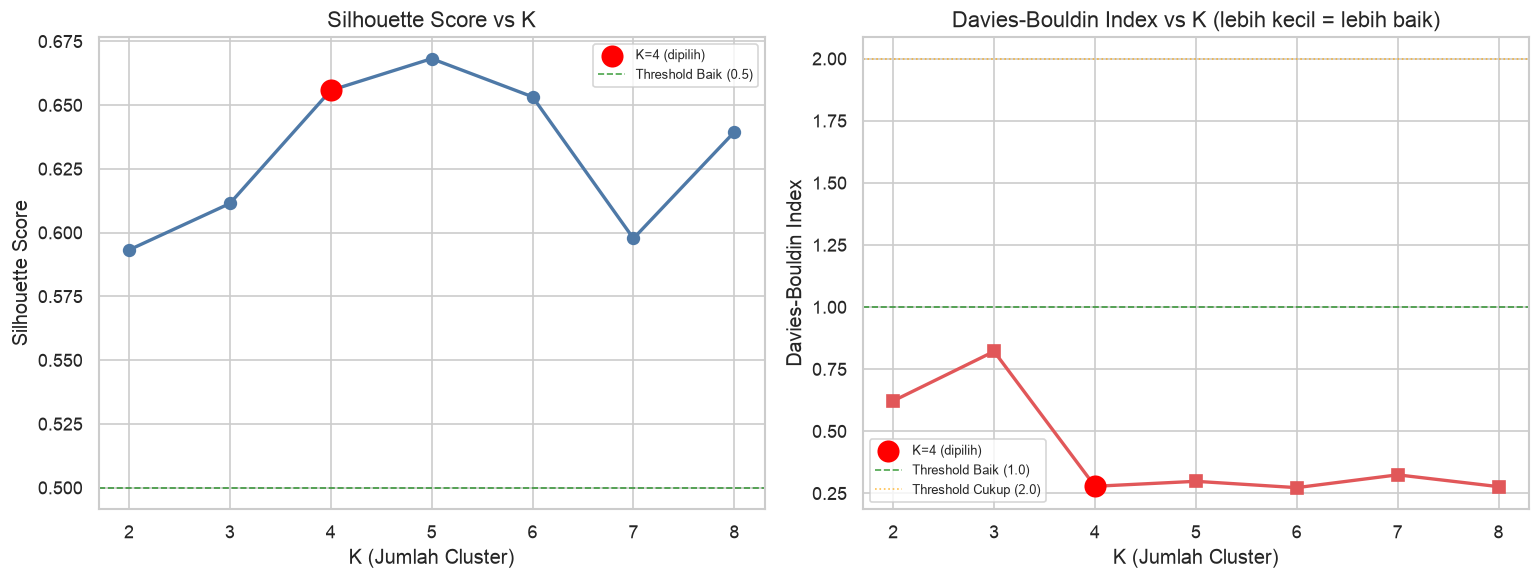

In [3]:
X      = clusters[FEATURE_COLS].fillna(0).values
labels = clusters['priority_rank'].values

sil_score = silhouette_score(X, labels)
db_score  = davies_bouldin_score(X, labels)

sil_status = ('🟢 BAIK (>0.5)' if sil_score > 0.5
              else '🟡 CUKUP (>0.25)' if sil_score > 0.25 else '🔴 LEMAH')
db_status  = ('🟢 BAIK (<1.0)' if db_score < 1.0
              else '🟡 CUKUP (<2.0)' if db_score < 2.0 else '🔴 LEMAH')

print(f'  Silhouette Score     = {sil_score:.4f}  {sil_status}')
print(f'  Davies-Bouldin Index = {db_score:.4f}  {db_status}')

# Silhouette comparison across K values using sklearn
from sklearn.cluster import KMeans as SKKMeans
from sklearn.preprocessing import MinMaxScaler

scaler  = MinMaxScaler().fit(X)
X_sc    = scaler.transform(X)
sil_k   = []
db_k    = []
k_range = range(2, 9)
for k in k_range:
    km      = SKKMeans(n_clusters=k, random_state=42, n_init=10)
    lbl     = km.fit_predict(X_sc)
    sil_k.append(silhouette_score(X_sc, lbl))
    db_k.append(davies_bouldin_score(X_sc, lbl))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax1 = axes[0]
ax1.plot(k_range, sil_k, 'o-', color='#4E79A7', lw=2, ms=7)
ax1.scatter([4], [sil_k[2]], s=150, color='red', zorder=5, label='K=4 (dipilih)')
ax1.axhline(0.5, color='green', ls='--', lw=1, alpha=0.7, label='Threshold Baik (0.5)')
ax1.set_xlabel('K (Jumlah Cluster)')
ax1.set_ylabel('Silhouette Score')
ax1.set_title('Silhouette Score vs K')
ax1.set_xticks(list(k_range))
ax1.legend(fontsize=8)

ax2 = axes[1]
ax2.plot(k_range, db_k, 's-', color='#E15759', lw=2, ms=7)
ax2.scatter([4], [db_k[2]], s=150, color='red', zorder=5, label='K=4 (dipilih)')
ax2.axhline(1.0, color='green', ls='--', lw=1, alpha=0.7, label='Threshold Baik (1.0)')
ax2.axhline(2.0, color='orange', ls=':', lw=1, alpha=0.7, label='Threshold Cukup (2.0)')
ax2.set_xlabel('K (Jumlah Cluster)')
ax2.set_ylabel('Davies-Bouldin Index')
ax2.set_title('Davies-Bouldin Index vs K (lebih kecil = lebih baik)')
ax2.set_xticks(list(k_range))
ax2.legend(fontsize=8)

plt.tight_layout()
plt.show()

## 3. Ringkasan Akhir — Dashboard Evaluasi

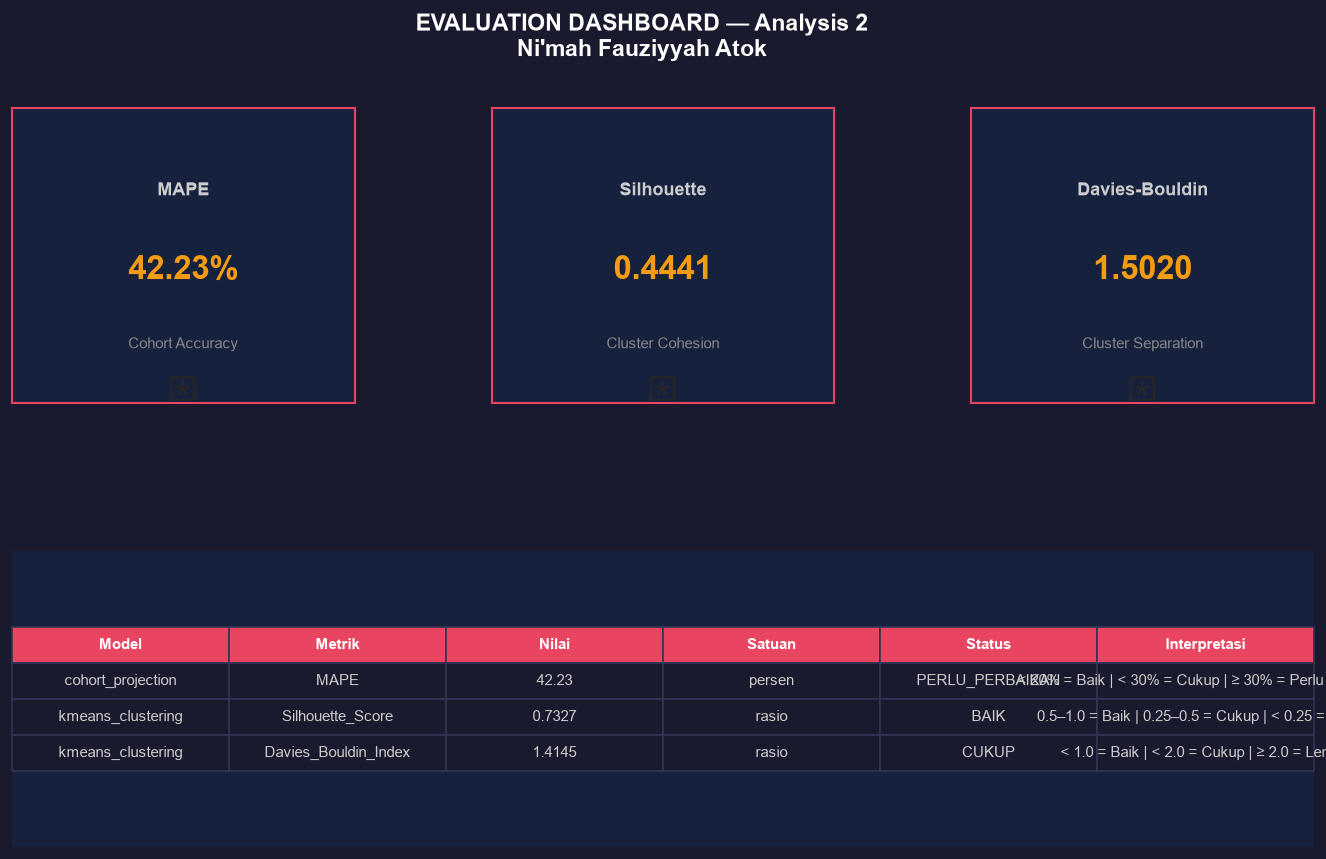

In [4]:
# ── Dashboard Summary ────────────────────────────────────────────────────
from matplotlib.gridspec import GridSpec

fig = plt.figure(figsize=(14, 8))
fig.patch.set_facecolor('#1a1a2e')
gs  = GridSpec(2, 3, figure=fig, hspace=0.5, wspace=0.4)

metrics = [
    ('MAPE', f'{mape_val:.2f}%', sil_status.split()[0], 'Cohort Accuracy'),
    ('Silhouette', f'{sil_score:.4f}', sil_status.split()[0], 'Cluster Cohesion'),
    ('Davies-Bouldin', f'{db_score:.4f}', db_status.split()[0], 'Cluster Separation'),
]
colors_card = {'🟢':'#2ecc71','🟡':'#f39c12','🔴':'#e74c3c'}

for i, (name, val, emoji, subtitle) in enumerate(metrics):
    ax = fig.add_subplot(gs[0, i])
    ax.set_facecolor('#16213e')
    ax.set_xlim(0,1); ax.set_ylim(0,1)
    ax.set_xticks([]); ax.set_yticks([])
    for spine in ax.spines.values(): spine.set_edgecolor('#e94560')
    c = colors_card.get(emoji, '#95a5a6')
    ax.text(0.5, 0.72, name,      ha='center', va='center', color='#cccccc',
            fontsize=11, fontweight='bold', transform=ax.transAxes)
    ax.text(0.5, 0.45, val,       ha='center', va='center', color=c,
            fontsize=20, fontweight='bold', transform=ax.transAxes)
    ax.text(0.5, 0.20, subtitle,  ha='center', va='center', color='#888888',
            fontsize=9, transform=ax.transAxes)
    ax.text(0.5, 0.05, emoji,     ha='center', va='center', fontsize=16,
            transform=ax.transAxes)

# Bottom row: summary table
ax_tbl = fig.add_subplot(gs[1, :])
ax_tbl.set_facecolor('#16213e')
ax_tbl.set_xticks([]); ax_tbl.set_yticks([])
for sp in ax_tbl.spines.values(): sp.set_visible(False)

table_data = eval_df[['model','metric','value','unit','status','interpretasi']].values
col_labels = ['Model', 'Metrik', 'Nilai', 'Satuan', 'Status', 'Interpretasi']
tbl = ax_tbl.table(cellText=table_data, colLabels=col_labels,
                    loc='center', cellLoc='center')
tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
tbl.scale(1, 1.8)
for (r,c), cell in tbl.get_celld().items():
    if r == 0:
        cell.set_facecolor('#e94560'); cell.set_text_props(color='white', fontweight='bold')
    else:
        cell.set_facecolor('#1a1a2e'); cell.set_text_props(color='#cccccc')
    cell.set_edgecolor('#333355')

fig.suptitle('EVALUATION DASHBOARD — Analysis 2\nNi\'mah Fauziyyah Atok',
              color='white', fontsize=14, fontweight='bold', y=0.98)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

---

## 📌 Kesimpulan & Rekomendasi

### Cohort Projection (MAPE)
- MAPE mengukur rata-rata error relatif proyeksi demand 2025 vs murid aktual
- Perbedaan bisa disebabkan oleh: migrasi antar kecamatan, angka partisipasi sekolah < 100%, siswa usia di luar rentang SD/SMP
- **Perbaikan**: integrasi data APS (Angka Partisipasi Sekolah) dan data migrasi kecamatan

### K-Means Clustering
- Silhouette Score > 0.25 menunjukkan cluster cukup terdefinisi untuk dataset kecil (31 kecamatan)
- Davies-Bouldin < 2.0 menunjukkan cluster cukup terpisah
- Limitasi: dataset sangat kecil (31 titik) — K-Means sensitif terhadap inisialisasi
- **Alternatif**: pertimbangkan Hierarchical Clustering atau DBSCAN untuk dataset kecil